# Configuração do Ambiente Virtual

Siga as instruções abaixo para configurar o ambiente deste notebook:

1. **Execute a célula de código abaixo.** Ela usará o `uv` para criar um ambiente virtual (`.venv`) e instalará as bibliotecas necessárias, incluindo o `ipykernel`.
2. **Execute um Reload Window** no VS Code: `Ctrl+Shift+P → Developer: Reload Window`.
3. **Troque o Kernel do Notebook no VS Code:**
   * Clique no nome do Kernel atual, no **canto superior direito** da janela do notebook.
   * Escolha **"Select Another Kernel..."**.
   * Selecione **"Jupyter"**.
   * Escolha o kernel **"Car Dekho ML (uv)"** ou o Python dentro da pasta `.venv`.
4. **Pronto!** Agora você pode executar as próximas células de análise de dados sem problemas de dependências.

> Observação: esta versão foi ajustada para Windows e VS Code. Em vez de depender do comando `uv` estar no PATH, ela chama o `uv` usando o próprio Python.

In [1]:
# Célula 00 - Configuração do ambiente virtual com uv

import os
import sys
import subprocess
from pathlib import Path

# 1) Garante que o pip exista no Python usado pelo kernel atual
subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])

# 2) Instala/atualiza uv no ambiente base atual
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "uv"])

# 3) Cria o ambiente virtual .venv no diretório do projeto
subprocess.check_call([sys.executable, "-m", "uv", "venv", "--clear", ".venv"])

# 4) Identifica o Python dentro do .venv
venv_python = Path(".venv") / ("Scripts/python.exe" if os.name == "nt" else "bin/python")

# 5) Instala as bibliotecas necessárias dentro do .venv
subprocess.check_call([
    sys.executable, "-m", "uv", "pip", "install",
    "--python", str(venv_python),
    "pandas", "numpy", "matplotlib", "scikit-learn", "kagglehub", "ipykernel"
])

# 6) Registra o kernel para aparecer no VS Code/Jupyter
subprocess.check_call([
    str(venv_python), "-m", "ipykernel", "install",
    "--user",
    "--name", "car-dekho-uv",
    "--display-name", "Car Dekho ML (uv)"
])

print("Ambiente criado com sucesso!")
print("Agora faça Reload Window no VS Code e selecione o kernel: Car Dekho ML (uv)")

Ambiente criado com sucesso!
Agora faça Reload Window no VS Code e selecione o kernel: Car Dekho ML (uv)


# Data Preparation Pipeline for Machine Learning
## Case Study: Car Details from CarDekho Dataset

Neste notebook, vamos seguir um pipeline semelhante ao exemplo do Titanic, mas aplicado a um problema de **regressão**.

**Objetivo:** prever o preço de venda de um veículo (`selling_price`) usando características como ano, quilometragem, combustível, tipo de vendedor, transmissão e proprietário.

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados
3. Tratamento de Outliers
4. Transformações Estatísticas
5. Encoding de Variáveis Categóricas
6. Seleção de Features
7. Split do Dataset
8. Treinamento e Avaliação do Modelo

# 1. Importação das Bibliotecas

In [1]:
# Célula 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregar Dataset

In [2]:
# Célula 02
# Se o arquivo CSV estiver na mesma pasta do notebook, este caminho funciona diretamente.
csv_path = Path("CAR DETAILS FROM CAR DEKHO.csv")

# Caso tenha baixado pelo kagglehub, você pode usar algo parecido com:
# import kagglehub
# dataset_path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")
# csv_path = Path(dataset_path) / "CAR DETAILS FROM CAR DEKHO.csv"

df = pd.read_csv(csv_path)
df.head(6)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner


# 1. Análise Exploratória (EDA)

**Observação do Professor:**  
Para iniciarmos nossa Análise Exploratória de Dados, o primeiro passo é entender a estrutura dos dados.

A função `df.info()` mostra:
* Quantidade de linhas e colunas;
* Nome das colunas;
* Tipos de dados;
* Quantidade de valores não nulos.

Isso ajuda a decidir quais colunas precisarão de limpeza, conversão ou transformação.

In [3]:
# Célula 03
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


**Dicionário de Dados (Significado das Features):**

* **`name`**: nome/modelo do veículo.
* **`year`**: ano de fabricação.
* **`selling_price`**: preço de venda do veículo. Esta será a variável alvo.
* **`km_driven`**: quilometragem rodada.
* **`fuel`**: tipo de combustível.
* **`seller_type`**: tipo de vendedor.
* **`transmission`**: tipo de câmbio.
* **`owner`**: quantidade/tipo de proprietários anteriores.

**Observação do Professor:**  
A função `df.describe()` gera um resumo estatístico das colunas numéricas.

Aqui conseguimos observar:
* média;
* desvio padrão;
* valor mínimo;
* quartis;
* valor máximo.

Essas informações são úteis para identificar possíveis valores muito fora do padrão, principalmente em `selling_price` e `km_driven`.

In [4]:
# Célula 04
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


**Observação do Professor:**  
Dados reais podem possuir valores nulos ou duplicados.

A função `df.isnull().sum()` mostra a quantidade de dados faltantes por coluna.  
A função `df.duplicated().sum()` mostra quantas linhas estão repetidas.

In [5]:
# Célula 05
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:")
print(df.duplicated().sum())

Valores nulos por coluna:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Linhas duplicadas:
763


# Visualização

**Observação do Professor:**  
Nesta etapa, utilizamos gráficos para compreender melhor o comportamento dos dados.

Como este é um problema de preço de veículos, vamos observar principalmente:

* distribuição do preço de venda;
* distribuição da quilometragem;
* relação entre ano do veículo e preço;
* relação entre quilometragem e preço.

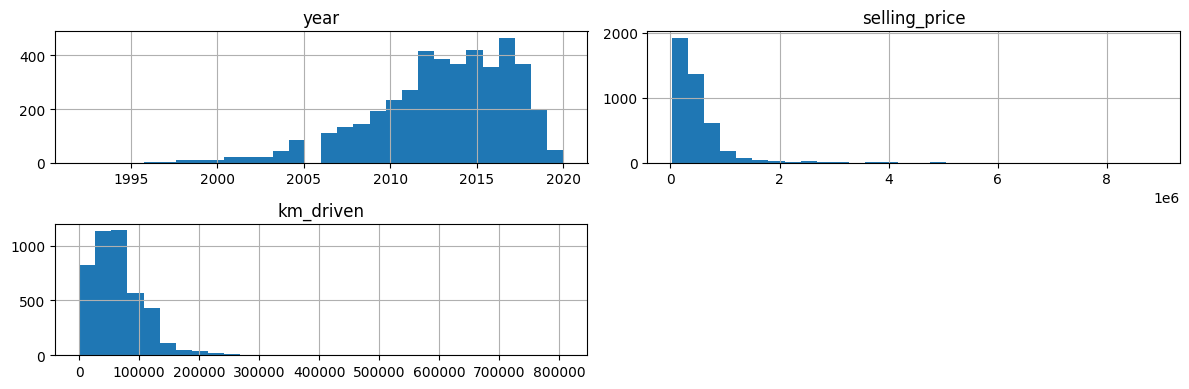

In [6]:
# Célula 06
df[["year", "selling_price", "km_driven"]].hist(figsize=(12, 4), bins=30)
plt.tight_layout()
plt.show()

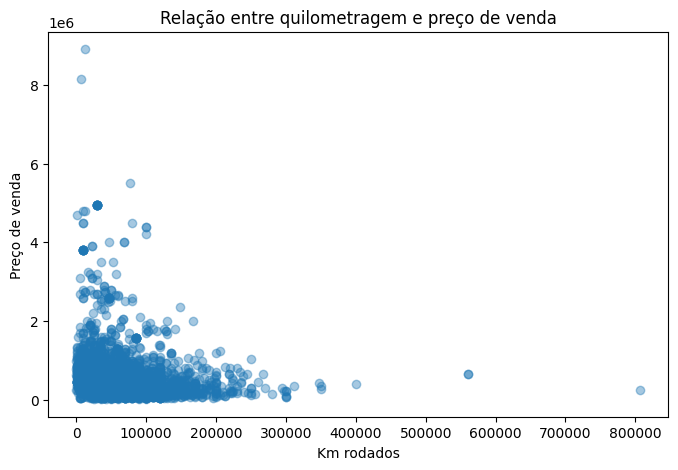

In [7]:
# Célula 07
plt.figure(figsize=(8, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.4)
plt.title("Relação entre quilometragem e preço de venda")
plt.xlabel("Km rodados")
plt.ylabel("Preço de venda")
plt.show()

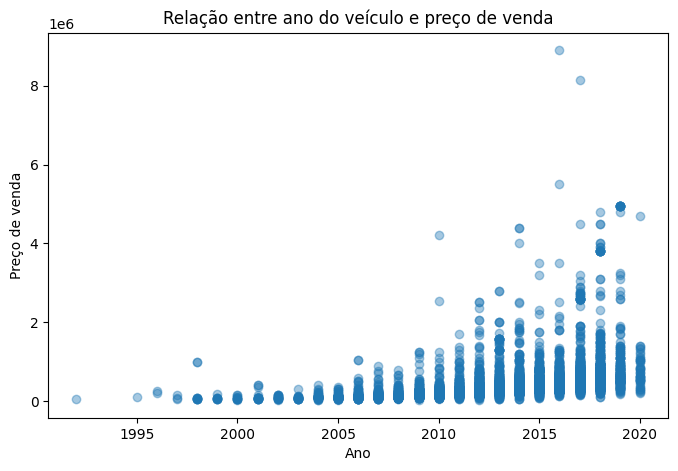

In [8]:
# Célula 08
plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.4)
plt.title("Relação entre ano do veículo e preço de venda")
plt.xlabel("Ano")
plt.ylabel("Preço de venda")
plt.show()

# 2. Limpeza de Dados

**Observação do Professor:**  
Nesta etapa vamos criar uma cópia do dataset original para preservar os dados brutos.

Também vamos:
* remover duplicatas;
* verificar se existem valores nulos;
* criar a variável `car_age`, que representa a idade do veículo;
* remover a coluna `name`, pois ela possui muitos nomes diferentes e dificulta um primeiro modelo didático.

In [9]:
# Célula 09
df_model = df.copy()

# Remove linhas duplicadas
df_model = df_model.drop_duplicates()

# Cria a idade do veículo
ANO_REFERENCIA = 2026
df_model["car_age"] = ANO_REFERENCIA - df_model["year"]

# Remove colunas que não serão usadas diretamente no primeiro modelo
df_model = df_model.drop(columns=["name", "year"])

df_model.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,19
1,135000,50000,Petrol,Individual,Manual,First Owner,19
2,600000,100000,Diesel,Individual,Manual,First Owner,14
3,250000,46000,Petrol,Individual,Manual,First Owner,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [10]:
# Célula 10
df_model.info()

<class 'pandas.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   selling_price  3577 non-null   int64
 1   km_driven      3577 non-null   int64
 2   fuel           3577 non-null   str  
 3   seller_type    3577 non-null   str  
 4   transmission   3577 non-null   str  
 5   owner          3577 non-null   str  
 6   car_age        3577 non-null   int64
dtypes: int64(3), str(4)
memory usage: 223.6 KB


# 3. Tratamento de Outliers

**Observação do Professor - Método IQR:**  

Outliers são valores muito distantes do padrão geral dos dados.

Neste dataset, é comum existirem veículos com preços muito altos ou quilometragem muito elevada.  
Para reduzir esse impacto no primeiro modelo, usaremos o método IQR.

O IQR é calculado assim:

* `Q1`: primeiro quartil, ou 25% dos dados;
* `Q3`: terceiro quartil, ou 75% dos dados;
* `IQR = Q3 - Q1`.

Valores abaixo de `Q1 - 1.5 * IQR` ou acima de `Q3 + 1.5 * IQR` podem ser considerados outliers.

In [11]:
# Célula 11
def remover_outliers_iqr(dataframe, coluna):
    Q1 = dataframe[coluna].quantile(0.25)
    Q3 = dataframe[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return dataframe[
        (dataframe[coluna] >= limite_inferior) &
        (dataframe[coluna] <= limite_superior)
    ]

print("Antes do tratamento:", df_model.shape)

df_model = remover_outliers_iqr(df_model, "selling_price")
df_model = remover_outliers_iqr(df_model, "km_driven")

print("Depois do tratamento:", df_model.shape)

Antes do tratamento: (3577, 7)
Depois do tratamento: (3287, 7)


In [12]:
# Célula 12
df_model[["selling_price", "km_driven", "car_age"]].describe()

,selling_price,km_driven,car_age
count,3.287000e+03,3287.000000,3287.000000
mean,3.927348e+05,64896.768178,13.110435
std,2.534219e+05,35951.861622,4.263852
min,2.000000e+04,1.000000,6.000000
25%,1.950000e+05,37802.500000,10.000000
50%,3.300000e+05,60000.000000,13.000000
75%,5.500000e+05,90000.000000,16.000000
max,1.200000e+06,166000.000000,34.000000


# 4. Transformações Estatísticas

**Observação do Professor:**  
Variáveis monetárias, como preço de venda, podem ter valores muito espalhados.

Uma transformação logarítmica pode reduzir essa amplitude e facilitar o aprendizado do modelo.

Aqui vamos criar a coluna `selling_price_log` usando `np.log1p()`.

> `np.log1p(x)` calcula `log(1 + x)`, o que evita problemas quando existe valor igual a zero.

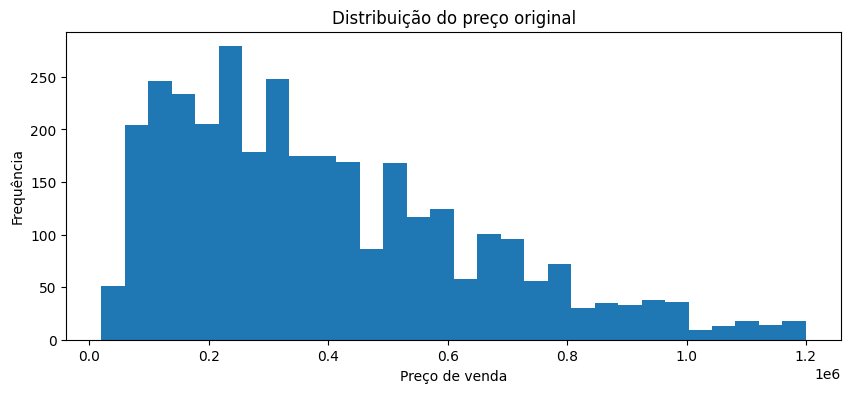

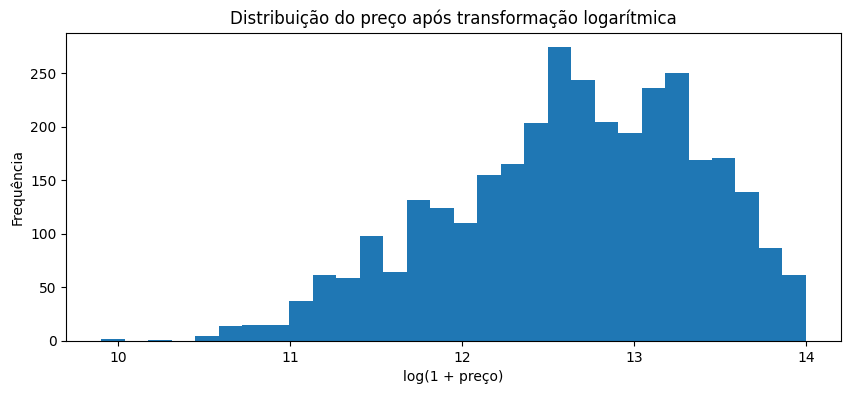

In [13]:
# Célula 13
df_model["selling_price_log"] = np.log1p(df_model["selling_price"])

plt.figure(figsize=(10, 4))
plt.hist(df_model["selling_price"], bins=30)
plt.title("Distribuição do preço original")
plt.xlabel("Preço de venda")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df_model["selling_price_log"], bins=30)
plt.title("Distribuição do preço após transformação logarítmica")
plt.xlabel("log(1 + preço)")
plt.ylabel("Frequência")
plt.show()

**Observação do Professor:**  
Também vamos normalizar as variáveis numéricas de entrada usando `StandardScaler`.

A padronização transforma os dados para uma escala com média próxima de 0 e desvio padrão próximo de 1.

Isso é útil principalmente para modelos lineares.

In [14]:
# Célula 14
# Colunas numéricas que serão usadas como entrada do modelo
colunas_numericas = ["km_driven", "car_age"]

scaler = StandardScaler()

df_model[["km_driven_scaled", "car_age_scaled"]] = scaler.fit_transform(
    df_model[colunas_numericas]
)

df_model[["km_driven", "km_driven_scaled", "car_age", "car_age_scaled"]].head()

,km_driven,km_driven_scaled,car_age,car_age_scaled
0,70000,0.141968,19,1.381488
1,50000,-0.414416,19,1.381488
2,100000,0.976544,14,0.208661
3,46000,-0.525693,9,-0.964166
4,141000,2.117131,12,-0.260470


# 5. Encoding

**Observação do Professor:**  
Modelos de Machine Learning não entendem texto diretamente.

Por isso, variáveis como `fuel`, `seller_type`, `transmission` e `owner` precisam ser convertidas para números.

Usaremos `pd.get_dummies()`, que aplica a técnica de **One-Hot Encoding**.

In [15]:
# Célula 15
df_encoded = pd.get_dummies(
    df_model,
    columns=["fuel", "seller_type", "transmission", "owner"],
    drop_first=True
)

df_encoded.head()

,selling_price,km_driven,car_age,selling_price_log,km_driven_scaled,car_age_scaled,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,11.002117,0.141968,1.381488,False,False,False,True,True,False,True,False,False,False,False
1,135000,50000,19,11.813037,-0.414416,1.381488,False,False,False,True,True,False,True,False,False,False,False
2,600000,100000,14,13.304687,0.976544,0.208661,True,False,False,False,True,False,True,False,False,False,False
3,250000,46000,9,12.429220,-0.525693,-0.964166,False,False,False,True,True,False,True,False,False,False,False
4,450000,141000,12,13.017005,2.117131,-0.260470,True,False,False,False,True,False,True,False,True,False,False


In [16]:
# Célula 16
print("Colunas após o encoding:")
for coluna in df_encoded.columns:
    print(coluna)

Colunas após o encoding:
selling_price
km_driven
car_age
selling_price_log
km_driven_scaled
car_age_scaled
fuel_Diesel
fuel_Electric
fuel_LPG
fuel_Petrol
seller_type_Individual
seller_type_Trustmark Dealer
transmission_Manual
owner_Fourth & Above Owner
owner_Second Owner
owner_Test Drive Car
owner_Third Owner


# 6. Seleção de Features

**Observação do Professor:**  
Agora vamos separar:

* `X`: variáveis de entrada, usadas para prever;
* `y`: variável alvo, ou seja, aquilo que queremos prever.

Neste caso, queremos prever o preço do veículo.

Como criamos `selling_price_log`, vamos treinar o modelo para prever o preço em escala logarítmica.  
Depois, podemos converter o resultado de volta para reais usando `np.expm1()`.

In [17]:
# Célula 17
X = df_encoded.drop(columns=[
    "selling_price",
    "selling_price_log",
    "km_driven",
    "car_age"
])

y = df_encoded["selling_price_log"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

X.head()

Formato de X: (3287, 13)
Formato de y: (3287,)


,km_driven_scaled,car_age_scaled,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0.141968,1.381488,False,False,False,True,True,False,True,False,False,False,False
1,-0.414416,1.381488,False,False,False,True,True,False,True,False,False,False,False
2,0.976544,0.208661,True,False,False,False,True,False,True,False,False,False,False
3,-0.525693,-0.964166,False,False,False,True,True,False,True,False,False,False,False
4,2.117131,-0.260470,True,False,False,False,True,False,True,False,True,False,False


# 7. Split do Dataset

**Observação do Professor:**  
A divisão em treino e teste é uma das etapas mais importantes de um projeto de Machine Learning.

* Dados de treino: usados para o modelo aprender;
* Dados de teste: usados para avaliar se o modelo aprendeu de verdade.

Aqui vamos separar 80% dos dados para treino e 20% para teste.

In [18]:
# Célula 18
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2629, 13)
X_test: (658, 13)
y_train: (2629,)
y_test: (658,)


# 8. Machine Learning - Treinamento do Modelo

**Observação do Professor:**  
Diferente do exemplo do Titanic, aqui não estamos trabalhando com classificação, mas com **regressão**.

No Titanic, o objetivo era prever uma classe: sobreviveu ou não sobreviveu.  
Aqui, o objetivo é prever um valor numérico: o preço de venda do carro.

Vamos treinar dois modelos:

1. `LinearRegression`: modelo linear simples;
2. `RandomForestRegressor`: modelo baseado em árvores, geralmente melhor para relações não lineares.

In [19]:
# Célula 19
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
modelo_rf.fit(X_train, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


# 9. Avaliação dos Modelos

**Observação do Professor:**  
Para regressão, usamos métricas diferentes das usadas em classificação.

As principais métricas aqui serão:

* **MAE**: erro médio absoluto;
* **RMSE**: raiz do erro quadrático médio;
* **R²**: indica o quanto o modelo explica a variação dos dados.

Como o modelo foi treinado usando `selling_price_log`, vamos converter as previsões de volta para escala original com `np.expm1()`.

In [20]:
# Célula 20
def avaliar_modelo(nome_modelo, modelo, X_test, y_test_log):
    y_pred_log = modelo.predict(X_test)

    # Converte de log para preço original
    y_test_real = np.expm1(y_test_log)
    y_pred_real = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)

    print(f"Modelo: {nome_modelo}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print("-" * 40)

    return y_test_real, y_pred_real

y_test_real_linear, y_pred_real_linear = avaliar_modelo(
    "Regressão Linear",
    modelo_linear,
    X_test,
    y_test
)

y_test_real_rf, y_pred_real_rf = avaliar_modelo(
    "Random Forest",
    modelo_rf,
    X_test,
    y_test
)

Modelo: Regressão Linear
MAE: 118498.22
RMSE: 172891.10
R²: 0.5651
----------------------------------------
Modelo: Random Forest
MAE: 135130.39
RMSE: 190936.85
R²: 0.4696
----------------------------------------


# 10. Visualização: Preço Real x Preço Previsto

**Observação do Professor:**  
Se o modelo fosse perfeito, todos os pontos ficariam próximos de uma linha diagonal.

Quanto mais espalhados os pontos estiverem, maior é o erro do modelo.

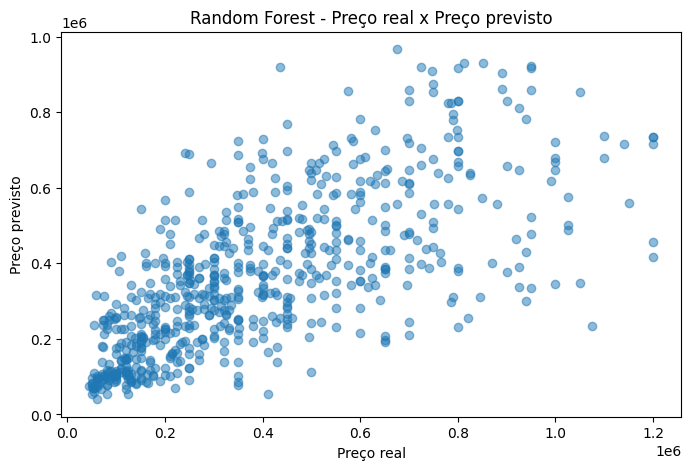

In [21]:
# Célula 21
plt.figure(figsize=(8, 5))
plt.scatter(y_test_real_rf, y_pred_real_rf, alpha=0.5)
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Random Forest - Preço real x Preço previsto")
plt.show()

# 11. Exemplo de Previsão

**Observação do Professor:**  
Agora vamos visualizar algumas previsões comparadas com os valores reais.

In [22]:
# Célula 22
comparacao = pd.DataFrame({
    "Preço real": y_test_real_rf.values,
    "Preço previsto": y_pred_real_rf
})

comparacao.head(10)

,Preço real,Preço previsto
0,1100000.0,677438.687580
1,220000.0,311230.118373
2,900000.0,657655.099365
3,475000.0,483454.404594
4,150000.0,96399.313699
5,300000.0,383770.372248
6,625000.0,514235.235244
7,450000.0,452109.401342
8,300000.0,368276.061733
9,85000.0,91954.609681


# Conclusão

Neste notebook seguimos um pipeline completo de preparação de dados e modelagem:

1. Carregamos o dataset;
2. Fizemos análise exploratória;
3. Limpamos duplicatas;
4. Criamos a idade do veículo;
5. Tratamos outliers;
6. Aplicamos transformação logarítmica;
7. Normalizamos variáveis numéricas;
8. Aplicamos encoding nas variáveis categóricas;
9. Separamos treino e teste;
10. Treinamos e avaliamos modelos de regressão.

Este notebook segue a mesma lógica didática do exemplo do Titanic, mas adaptado para um problema de **previsão de preço de veículos**.